In [304]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   

# for linear regression
from sklearn.linear_model import LinearRegression #for machine learning
from sklearn.preprocessing import StandardScaler #for feature scaling
from sklearn.model_selection import train_test_split #for splitting data into training and testing sets
from sklearn.metrics import mean_squared_error, r2_score #for evaluating the model


In [305]:
df=pd.read_csv('Data/Car_sales.csv')
df.head(3)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner


In [306]:
df['fuel'].unique()


array(['Petrol', 'Diesel', 'CNG', 'LPG', 'Electric'], dtype=object)

In [307]:
fuel_id={
    'Petrol':0,
    'Diesel':1,
    'Electric':2,  
    'CNG':3,
    'LPG':4
}
df['fuel_id']=df['fuel'].map(fuel_id)

In [308]:
seller_type_id={
    'Dealer':1,
    'Individual':0,
    'Trustmark Dealer':2
    }
df['seller_type_id']=df['seller_type'].map(seller_type_id)

In [309]:
# transfromation
df['transmission'].unique()

array(['Manual', 'Automatic'], dtype=object)

In [310]:
transformation_id={
    'Manual':1,
    'Automatic':0
}
df['transmission']=df['transmission'].map(transformation_id)

In [311]:
owner_id={
    'First Owner':0,
    'Second Owner':1,
    'Third Owner':2,
    'Fourth & Above Owner':3,
    'Test Driver Car':4
}
df['owner_id']=df['owner'].map(owner_id)

In [312]:
df

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,fuel_id,seller_type_id,owner_id
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,1,First Owner,0,0,0.0
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,1,First Owner,0,0,0.0
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,1,First Owner,1,0,0.0
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,1,First Owner,0,0,0.0
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,1,Second Owner,1,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999,80000,Diesel,Individual,1,Second Owner,1,0,1.0
4336,Hyundai i20 Magna 1.4 CRDi,2014,409999,80000,Diesel,Individual,1,Second Owner,1,0,1.0
4337,Maruti 800 AC BSIII,2009,110000,83000,Petrol,Individual,1,Second Owner,0,0,1.0
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000,90000,Diesel,Individual,1,First Owner,1,0,0.0


In [313]:
# feauture and eventarget
feature=['year','km_driven','fuel_id','seller_type_id','transmission','owner_id']
target='selling_price'

In [314]:
x=df[feature] #MULTI_dim list
y=df[target] #single_dim list

In [315]:
#train test split
x_train,x_test,y_train,y_test =train_test_split(x,y,test_size=0.2,random_state=42)


In [316]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)

In [317]:
# feature scaling
# standard scalar -> (xi-mean)/std
# only scale
scalar=StandardScaler()


In [318]:
x_train_scale=scalar.fit_transform(x_train)
x_test_scale=scalar.transform(x_test)

In [319]:
mdel=LinearRegression()
mdel.fit(x_train_scale ,y_train)
y_pred=mdel.predict(x_test_scale)

In [320]:
from sklearn.metrics import mean_squared_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse}')
print(f'R2 Score: {r2}')

RMSE: 434764.39678331214
R2 Score: 0.3806078464074808


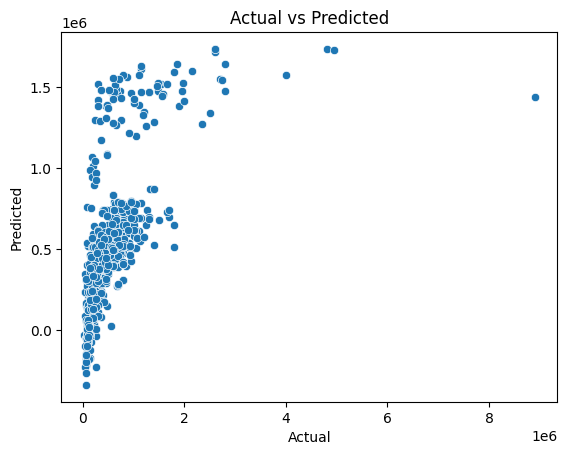

In [321]:
# visualization
#new data prediction
# use of flatten is same a ravel 

sns.scatterplot(x=y_test.values.flatten(), y=y_pred.flatten())
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [322]:
# for straight line
x_min, x_max= [y_test.min(), y_test.max()]
y_min, y_max= [y_test.min(), y_pred.max()]

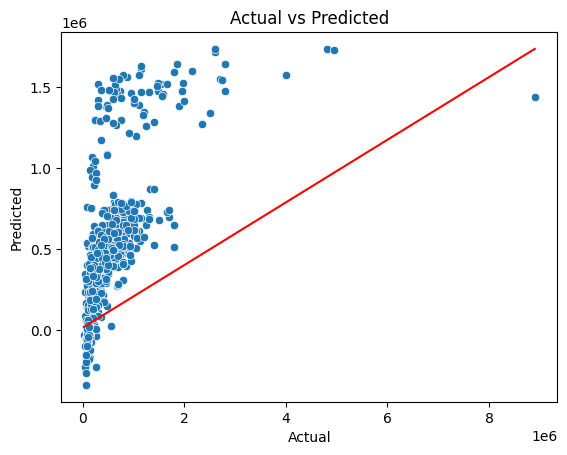

In [299]:
#visualization of straight line graph
sns.scatterplot(x=y_test.values.flatten(), y=y_pred.flatten())
plt.plot([x_min, x_max], [y_min, y_max], color='red')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [300]:
# random forest regressor
from sklearn.ensemble import RandomForestRegressor

In [301]:
rf_model= RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)
rf_pred=rf_model.predict(x_test)

In [302]:
rf_rmse= np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2= r2_score(y_test, rf_pred)

print(f'random forest RMSE: {rf_rmse}')
print(f'random forest R2 score(accuracy): {rf_r2}')

random forest RMSE: 391141.06953078636
random forest R2 score(accuracy): 0.4986689620519025


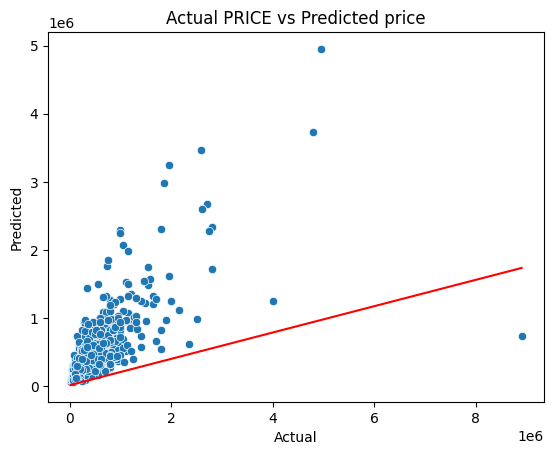

In [303]:
sns.scatterplot(x=y_test.values.flatten(), y=rf_pred.flatten())
plt.plot([x_min, x_max], [y_min, y_max], color='red')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual PRICE vs Predicted price")
plt.show()